"""
Interactive voltage-movie viewer for Jupyter notebooks.

Features
- Loads only a specified frame range from an HDF5 movie (no full-file read).
- Extracts Allen region outlines from specs["extra_specs"]["allenMapEdgeOutline"].
- Optionally masks the movie to V1 (default outline index 37, matching your example).
- Interactive slider to scrub frames.
- Always uses the seismic colormap.

Assumptions
- HDF5 structure: f["mov"] is shaped (T, Y, X) like your example.
- Specs contain: "binning", "spaceorigin", and extra_specs["allenMapEdgeOutline"].
"""

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, Play, VBox, HBox, jslink
from skimage.draw import polygon2mask
from pathlib import Path
from scipy.signal import butter, sosfiltfilt
import cv2

%matplotlib widget

In [2]:
def load_movie_and_specs(path_movie: str | Path, t_start: int = 0, t_stop: int | None = None):
    """
    Load a frame range from an HDF5 voltage movie and read outline metadata.

    Parameters
    ----------
    path_movie : str | Path
        Absolute path to the .h5 file.
    t_start : int
        Start frame index (inclusive).
    t_stop : int | None
        Stop frame index (exclusive). If None, loads to end.

    Returns
    -------
    mov : np.ndarray
        Movie array with shape (T, Y, X), dtype float32.
    meta : dict
        Contains:
        - "binning" (float)
        - "spaceorigin" (np.ndarray shape (2,))
        - "raw_outlines" (np.ndarray shape (n_regions, 2, n_points))
        - "fps" (float | None)
    """
    path_movie = Path(path_movie)

    with h5py.File(path_movie, "r") as f:
        specs = f["specs"]
        dset = f["mov"]

        T = int(dset.shape[0])
        if t_stop is None:
            t_stop = T
        if not (0 <= t_start < t_stop <= T):
            raise ValueError(f"Invalid frame range: [{t_start}, {t_stop}) for T={T}")

        mov = np.array(dset[t_start:t_stop, :, :], dtype=np.float32)

        binning = float(np.array(specs["binning"][()]).squeeze())
        spaceorigin = np.array(specs["spaceorigin"][()]).squeeze()
        raw_outlines = np.array(specs["extra_specs"]["allenMapEdgeOutline"][()]).squeeze()

        fps = float(np.array(specs["fps"][()]).squeeze())
        timeorigin = specs["timeorigin"][()].squeeze() 
        timebinning = specs["timebinning"][()].squeeze() 
        timestamps_table = specs["extra_specs"]["timestamps_table"][()].squeeze()
        timestamps_table_names = specs["extra_specs"]["timestamps_table_names"][()].squeeze() 
        timestamps_table_names = b''.join(timestamps_table_names.flatten()).decode("utf-8").split(';')

    onsets, offsets = get_ttl_trace(timestamps_table, timestamps_table_names, timeorigin, timebinning)

    meta = {"binning": binning, "spaceorigin": spaceorigin, "raw_outlines": raw_outlines, "fps": fps, "onsets": onsets, "offsets": offsets}
    return mov, meta

def outlines_to_pixel_coords(raw_outlines: np.ndarray, binning: float, spaceorigin: np.ndarray):
    """
    Convert raw Allen outlines into pixel coordinates aligned with the movie.

    This follows the transform pattern in your previous code:
      spaceorigin' = (spaceorigin - 1) / binning + 1
      outlines_px  = raw_outlines / binning
      then shift outlines by spaceorigin' (note the axis ordering below)

    Parameters
    ----------
    raw_outlines : np.ndarray
        Shape (n_regions, 2, n_points). Axis 1 is [Y, X] in the raw convention.
    binning : float
        Binning factor from specs.
    spaceorigin : np.ndarray
        Shape (2,).

    Returns
    -------
    outlines_px : np.ndarray
        Pixel-aligned outlines, same shape as raw_outlines.
    """
    so = (np.array(spaceorigin, dtype=float).squeeze() - 1.0) / float(binning) + 1.0
    outlines_px = np.array(raw_outlines, dtype=float) / float(binning)

    # Match your prior adjustment convention:
    outlines_px[:, 0, :] -= (so[1] - 1.0)  # Y shift uses so[1]
    outlines_px[:, 1, :] -= (so[0] - 1.0)  # X shift uses so[0]

    return outlines_px

def region_mask_from_outline_indices(frame_shape_yx: tuple[int, int], outlines_px: np.ndarray, indices: list[int]):
    """
    Build a boolean mask from one or more outline indices.

    Parameters
    ----------
    frame_shape_yx : (int, int)
        (Y, X) shape of a movie frame.
    outlines_px : np.ndarray
        Pixel-aligned outlines, shape (n_regions, 2, n_points), [Y, X].
    indices : list[int]
        Outline indices to include (e.g., V1 index [37]).

    Returns
    -------
    mask : np.ndarray
        Boolean mask with shape (Y, X). True inside ROI.
    """
    mask = np.zeros(frame_shape_yx, dtype=bool)

    for i in indices:
        outline = outlines_px[i, :, :]  # (2, n_points)
        valid = ~np.isnan(outline).any(axis=0)
        if valid.sum() < 3:
            continue

        y = outline[0, valid]
        x = outline[1, valid]

        roi = polygon2mask(frame_shape_yx, np.column_stack((y, x))).astype(bool)

        # Keep consistent with your earlier code (orientation match)
        roi = np.flipud(roi)

        mask |= roi

    return mask

def bbox_from_outline(outline_yx: np.ndarray):
    """
    Compute an axis-aligned bounding box from a single region outline.

    Parameters
    ----------
    outline_yx : np.ndarray
        Shape (2, N) with rows [Y, X]. Can include NaNs.

    Returns
    -------
    y0, y1, x0, x1 : int
        Bounding box indices (y1/x1 are exclusive).
    """
    valid = ~np.isnan(outline_yx).any(axis=0)
    if valid.sum() < 2:
        raise ValueError("Outline has too few valid points to compute a bounding box.")

    y = outline_yx[0, valid]
    x = outline_yx[1, valid]

    y0 = int(np.floor(y.min()))
    y1 = int(np.ceil(y.max())) + 1
    x0 = int(np.floor(x.min()))
    x1 = int(np.ceil(x.max())) + 1
    return y0, y1, x0, x1

def expand_bbox(y0, y1, x0, x1, frame_shape_yx, pad_frac=0.25):
    """
    Expand a bounding box by a fraction of its width/height on all sides.

    Interprets pad_frac as: add (pad_frac * width) to LEFT and RIGHT,
    and (pad_frac * height) to TOP and BOTTOM.

    Parameters
    ----------
    y0, y1, x0, x1 : int
        Original bbox (exclusive max).
    frame_shape_yx : (int, int)
        (H, W) of the full frame.
    pad_frac : float
        Fraction of bbox width/height to add on each side.

    Returns
    -------
    y0e, y1e, x0e, x1e : int
        Expanded bbox, clipped to image bounds.
    """
    H, W = frame_shape_yx
    h = max(1, y1 - y0)
    w = max(1, x1 - x0)

    pad_y = int(np.round(pad_frac * h))
    pad_x = int(np.round(pad_frac * w))

    y0e = max(0, y0 - pad_y)
    y1e = min(H, y1 + pad_y)
    x0e = max(0, x0 - pad_x)
    x1e = min(W, x1 + pad_x)

    return y0e, y1e, x0e, x1e

def robust_symmetric_limits(mov: np.ndarray, p: float = 99.0):
    """
    Compute symmetric (vmin, vmax) around zero using a robust percentile over the whole movie.

    Parameters
    ----------
    mov : np.ndarray
        Movie array (T, Y, X), can include NaNs.
    p : float
        Percentile of |values| used to set the limit.

    Returns
    -------
    vmin, vmax : float, float
        Symmetric limits.
    """
    vals = mov[np.isfinite(mov)]
    if vals.size == 0:
        return -1.0, 1.0
    m = np.percentile(np.abs(vals), p)
    if not np.isfinite(m) or m == 0:
        m = float(np.nanmax(np.abs(vals))) if np.nanmax(np.abs(vals)) > 0 else 1.0
    return -m, m

def bandpass_movie(
    clip: np.ndarray,
    fs: float,
    f_lo: float = 25.0,
    f_hi: float = 50.0,
    order: int = 4,
):
    """
    Bandpass filter a voltage movie clip along the time axis.

    Filtering is applied independently to each pixel's time series,
    using a zero-phase Butterworth filter (no phase distortion).

    Parameters
    ----------
    clip : np.ndarray
        Movie clip of shape (T, Y, X).
    fs : float
        Sampling rate in Hz (frames per second).
    f_lo : float
        Low cutoff frequency (Hz). Default = 25 Hz.
    f_hi : float
        High cutoff frequency (Hz). Default = 50 Hz.
    order : int
        Butterworth filter order. Default = 4.

    Returns
    -------
    clip_bp : np.ndarray
        Bandpass-filtered movie, same shape as input.
    """
    if clip.ndim != 3:
        raise ValueError("clip must have shape (T, Y, X)")

    nyq = 0.5 * fs
    if not (0 < f_lo < f_hi < nyq):
        raise ValueError(f"Invalid band: f_lo={f_lo}, f_hi={f_hi}, Nyquist={nyq}")

    # Design filter in second-order sections (numerically stable)
    sos = butter(
        order,
        [f_lo / nyq, f_hi / nyq],
        btype="bandpass",
        output="sos",
    )

    # Reshape to (T, Npix) for efficient filtering
    T, Y, X = clip.shape
    clip_2d = clip.reshape(T, Y * X)

    # Zero-phase filtering along time
    clip_bp_2d = sosfiltfilt(sos, clip_2d, axis=0)

    # Restore original shape
    clip_bp = clip_bp_2d.reshape(T, Y, X)

    return clip_bp

In [3]:
def get_ttl_trace(timestamps_table, timestamps_table_names, timeorigin, timebinning=1):
    """
    Extracts the TTL trace from the movie specs.

    Args:
    - timestamps_table (np.ndarray): Timestamps table containing TTL data.
    - timestamps_table_names (np.ndarray): Column names for the timestamps table.
    - timeorigin (int): Starting index for the TTL signal.
    - timebinning (int, optional): Time binning factor for downsampling (default: 1).

    Returns:
    - np.ndarray: Extracted TTL signal.
    """
  
    # Get the column index for 'behavior_ttl'
    ttl_column = timestamps_table_names.index("behavior_ttl")

    # Extract the raw TTL signal starting from `timeorigin`
    ttl_signal_raw = timestamps_table[ttl_column, int(timeorigin):]

    # Apply binning if `timebinning` is greater than 1
    if timebinning > 1:
        # Ensure the length of ttl_signal_raw is divisible by timebinning
        trimmed_length = len(ttl_signal_raw) - (len(ttl_signal_raw) % timebinning)
        ttl_signal_raw = ttl_signal_raw[:trimmed_length]
        
        # Reshape, average over bins, and round the result
        ttl_signal = np.round(np.mean(ttl_signal_raw.reshape(-1, timebinning), axis=1))
    else:
        ttl_signal = ttl_signal_raw

    onsets = np.where(np.diff(ttl_signal) == 1)[0] 
    offsets = np.where(np.diff(ttl_signal) == -1)[0] 

    return onsets, offsets

In [4]:
def movie_power_spectrum(
    movie,
    fs,
    band=(25, 50),
    detrend=True,
    window="hann",
    average="mean",   # "mean" or "median"
    plot=True,
):
    """
    Compute per-pixel power spectra along time, then average across pixels.

    Parameters
    ----------
    movie : array, shape (T, H, W)
        Movie clip (time first). Can contain NaNs (they'll be handled).
    fs : float
        Sampling rate in Hz (frames per second).
    band : tuple (f_lo, f_hi)
        Frequency band of interest (Hz). Used for plotting and band power map.
    detrend : bool
        If True, remove per-pixel mean (DC) before FFT.
    window : {"hann", None}
        Window applied along time to reduce leakage.
    average : {"mean", "median"}
        How to aggregate spectra across pixels.
    plot : bool
        If True, plot the averaged power spectrum and highlight the band.

    Returns
    -------
    freqs : array, shape (F,)
        One-sided frequency axis (Hz).
    avg_psd : array, shape (F,)
        Averaged per-pixel power spectrum.
    band_power_map : array, shape (H, W)
        Average power in the band per pixel.
    """

    # ---- Basic shape checks ----
    if movie.ndim != 3:
        raise ValueError("movie must have shape (T, H, W)")
    T, H, W = movie.shape

    # ---- Reshape to (T, Npix) for vectorized FFT ----
    X = movie.reshape(T, -1).astype(float)

    # Handle NaNs: simplest approach = fill NaNs with per-pixel mean (or 0 if all NaN)
    # This keeps the function simple and avoids dropping pixels.
    pix_mean = np.nanmean(X, axis=0)
    pix_mean = np.where(np.isfinite(pix_mean), pix_mean, 0.0)
    inds = ~np.isfinite(X)
    if np.any(inds):
        X[inds] = np.take(pix_mean, np.where(inds)[1])

    # ---- Detrend / remove DC ----
    if detrend:
        X = X - X.mean(axis=0, keepdims=True)

    # ---- Window ----
    if window is None:
        w = np.ones(T)
        w_norm = 1.0
    elif window == "hann":
        w = np.hanning(T)
        # Normalization to make power comparable across window choices
        w_norm = np.mean(w**2)
    else:
        raise ValueError("window must be 'hann' or None")

    Xw = X * w[:, None]

    # ---- FFT (one-sided) ----
    F = np.fft.rfft(Xw, axis=0)  # (Fbins, Npix)
    freqs = np.fft.rfftfreq(T, d=1.0 / fs)

    # Power spectrum (not exactly Welch PSD, but simple and often fine)
    # Normalize by T and window power so scale is stable-ish across clips.
    power = (np.abs(F) ** 2) / (T * T * w_norm)  # (Fbins, Npix)

    # ---- Average across pixels ----
    if average == "mean":
        avg_psd = power.mean(axis=1)
    elif average == "median":
        avg_psd = np.median(power, axis=1)
    else:
        raise ValueError("average must be 'mean' or 'median'")

    # ---- Band power map (mean power in band per pixel) ----
    f_lo, f_hi = band
    band_mask = (freqs >= f_lo) & (freqs <= f_hi)
    if not np.any(band_mask):
        raise ValueError("band does not overlap available frequency axis")
    band_power = power[band_mask, :].mean(axis=0)  # (Npix,)
    band_power_map = band_power.reshape(H, W)

    # ---- Plot ----
    if plot:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(freqs, avg_psd)

        ax.axvspan(f_lo, f_hi, alpha=0.2)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power (a.u.)")
        ax.set_title("Averaged per-pixel power spectrum")
        ax.set_xlim(f_lo-5, f_hi+5)
        plt.tight_layout()

    return freqs, avg_psd, band_power_map

def bbox_from_outline_with_yflip(outline_yx: np.ndarray, frame_shape_yx: tuple[int, int]):
    """
    Compute an axis-aligned bounding box from a single region outline AFTER vertically flipping it.

    Vertical flip is done in image-pixel space:
        y -> (H - 1) - y

    Parameters
    ----------
    outline_yx : np.ndarray
        Shape (2, N) with rows [Y, X]. Can include NaNs.
    frame_shape_yx : (int, int)
        (H, W) of the full frame.

    Returns
    -------
    y0, y1, x0, x1 : int
        Bounding box indices (y1/x1 are exclusive) in the movie's pixel coordinates.
    """
    H, W = frame_shape_yx
    valid = ~np.isnan(outline_yx).any(axis=0)
    if valid.sum() < 2:
        raise ValueError("Outline has too few valid points to compute a bounding box.")

    y = outline_yx[0, valid]
    x = outline_yx[1, valid]

    y = (H - 1) - y  # flip for consistency with your plotting

    y0 = int(np.floor(y.min()))
    y1 = int(np.ceil(y.max())) + 1
    x0 = int(np.floor(x.min()))
    x1 = int(np.ceil(x.max())) + 1

    # Clip just in case
    y0 = max(0, min(H - 1, y0))
    y1 = max(1, min(H, y1))
    x0 = max(0, min(W - 1, x0))
    x1 = max(1, min(W, x1))

    return y0, y1, x0, x1

def expand_bbox(y0, y1, x0, x1, frame_shape_yx, pad_frac=0.25):
    """
    Expand a bounding box by a fraction of its width/height on all sides.

    Adds (pad_frac * width) to LEFT and RIGHT, and (pad_frac * height) to TOP and BOTTOM.
    """
    H, W = frame_shape_yx
    h = max(1, y1 - y0)
    w = max(1, x1 - x0)

    pad_y = int(np.round(pad_frac * h))
    pad_x = int(np.round(pad_frac * w))

    y0e = max(0, y0 - pad_y)
    y1e = min(H, y1 + pad_y)
    x0e = max(0, x0 - pad_x)
    x1e = min(W, x1 + pad_x)

    return y0e, y1e, x0e, x1e

def crop_to_expanded_v1_rect(mov, outlines_px, v1_index=37, pad_frac=0.25, flip_y=True):
    """
    True-crop movie to an expanded bounding box around the V1 outline.
    Also returns outlines transformed into the cropped coordinate system.

    Returns
    -------
    mov_crop : (T, Hc, Wc)
    outlines_crop : (n_regions, 2, n_points) in cropped coords, ready to plot on mov_crop
    bbox : (y0, y1, x0, x1) in original coords
    """
    if mov.ndim != 3:
        raise ValueError("mov must be (T, Y, X)")
    H, W = mov.shape[1:3]

    # Copy outlines and optionally flip vertically in full-frame coords
    o = outlines_px.copy()
    if flip_y:
        o[:, 0, :] = (H - 1) - o[:, 0, :]

    # V1 bbox in the same coords we will plot
    v1 = o[v1_index]
    valid = ~np.isnan(v1).any(axis=0)
    if valid.sum() < 3:
        raise ValueError("V1 outline has too few valid points.")

    y = v1[0, valid]
    x = v1[1, valid]

    y0 = int(np.floor(y.min())); y1 = int(np.ceil(y.max())) + 1
    x0 = int(np.floor(x.min())); x1 = int(np.ceil(x.max())) + 1

    # Expand bbox by pad_frac on each side
    h = max(1, y1 - y0)
    w = max(1, x1 - x0)
    pad_y = int(np.round(pad_frac * h))
    pad_x = int(np.round(pad_frac * w))

    y0 = max(0, y0 - pad_y); y1 = min(H, y1 + pad_y)
    x0 = max(0, x0 - pad_x); x1 = min(W, x1 + pad_x)

    mov_crop = mov[:, y0:y1, x0:x1]

    # Shift outlines into cropped coords
    o[:, 0, :] -= y0
    o[:, 1, :] -= x0

    # Clip outlines to cropped frame so they can't affect autoscaling
    Hc, Wc = mov_crop.shape[1:3]
    yy = o[:, 0, :]
    xx = o[:, 1, :]
    oob = (yy < 0) | (yy > (Hc - 1)) | (xx < 0) | (xx > (Wc - 1))
    o[:, 0, :][oob] = np.nan
    o[:, 1, :][oob] = np.nan

    return mov_crop, o, (y0, y1, x0, x1)

def save_movie(
    mov: np.ndarray,
    out_avi_path: str,
    title: str = "Voltage movie",
    interval_ms: int = 30,
    outlines_px: np.ndarray | None = None,
    show_outlines: bool = False,
    dpi: int = 150,
):
    """
    Save a voltage movie to an .avi file with the same look as view_movie:
    - seismic colormap
    - robust symmetric color limits
    - title
    - colorbar
    - optional outlines overlay

    Parameters
    ----------
    mov : np.ndarray
        Movie array of shape (T, Y, X). NaNs are allowed.
    out_avi_path : str
        Output path for the .avi file.
    title : str
        Figure title.
    interval_ms : int
        Time between frames in milliseconds. Determines fps = 1000/interval_ms.
    cbar_label : str
        Colorbar label text.
    outlines_px : np.ndarray | None
        Outlines in the SAME coordinate system as the movie being saved,
        shape (n_regions, 2, n_points) with [Y, X]. If show_outlines=True, must be provided.
    show_outlines : bool
        Whether to overlay outlines.
    dpi : int
        DPI used when rendering frames.

    Returns
    -------
    out_avi_path : str
        The output path (for convenience).
    """

    T, H, W = mov.shape

    # Robust symmetric limits (same logic as viewer)
    vals = mov[np.isfinite(mov)]
    if vals.size == 0:
        vmin, vmax = -1.0, 1.0
    else:
        m = np.percentile(np.abs(vals), 99.0)
        if not np.isfinite(m) or m == 0:
            m = float(np.nanmax(np.abs(vals))) if np.nanmax(np.abs(vals)) > 0 else 1.0
        vmin, vmax = -m, m

    fps = 1000.0 / float(interval_ms)

    # Create a figure that matches the viewer
    fig, ax = plt.subplots(figsize=(6, 6), dpi=dpi)
    im = ax.imshow(
        mov[0],
        cmap="seismic",
        vmin=vmin,
        vmax=vmax,
        origin="upper",
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$\Delta F/F$")

    # Draw outlines once (they don't change over time)
    if show_outlines:
        n_regions = outlines_px.shape[0]
        for k in range(n_regions):
            o = outlines_px[k]  # (2, N) [Y, X]
            valid = ~np.isnan(o).any(axis=0)
            if valid.sum() < 2:
                continue
            y = o[0, valid]
            x = o[1, valid]
            ax.plot(x, y, color='black', linewidth=0.7)

    fig.tight_layout()

    # Render one frame to determine output video size (in pixels)
    fig.canvas.draw()
    w_px, h_px = fig.canvas.get_width_height()

    # Setup AVI writer (MJPG is broadly compatible)
    fourcc = cv2.VideoWriter_fourcc(*"MJPG")
    writer = cv2.VideoWriter(out_avi_path, fourcc, fps, (w_px, h_px))

    if not writer.isOpened():
        plt.close(fig)
        raise RuntimeError(
            "Could not open VideoWriter. "
            "Check that the output directory exists and that OpenCV is installed with video support."
        )

    try:
        for i in range(T):
            im.set_data(mov[i])
            fig.canvas.draw()

            # Backend-safe framebuffer grab
            buf = np.asarray(fig.canvas.buffer_rgba())
            rgb = buf[..., :3].copy()   # RGBA -> RGB

            # OpenCV expects BGR
            bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
            writer.write(bgr)

    finally:
        writer.release()
        plt.close(fig)

    return out_avi_path

def view_movie(
    mov: np.ndarray,
    title: str = "Voltage movie",
    interval_ms: int = 30,
    outlines_px: np.ndarray | None = None,
    show_outlines: bool = False,
    outline_color: str = "white",
    outline_lw: float = 0.7,
):
    """
    Interactive voltage movie viewer (play + slider + colorbar).
    Optionally overlays all region outlines in white.

    Note: requires an interactive backend like `%matplotlib widget` for live updates.
    """
    if mov.ndim != 3:
        raise ValueError("mov must have shape (T, Y, X)")

    T = mov.shape[0]

    slider = IntSlider(value=0, min=0, max=T - 1, step=1, description="Frame", continuous_update=True)
    play = Play(value=0, min=0, max=T - 1, step=1, interval=interval_ms)
    jslink((play, "value"), (slider, "value"))

    vals = mov[np.isfinite(mov)]
    if vals.size == 0:
        vmin, vmax = -1.0, 1.0
    else:
        m = np.percentile(np.abs(vals), 99.0)
        if not np.isfinite(m) or m == 0:
            m = float(np.nanmax(np.abs(vals))) if np.nanmax(np.abs(vals)) > 0 else 1.0
        vmin, vmax = -m, m

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(
        mov[0],
        cmap="seismic",
        vmin=vmin,
        vmax=vmax,
        origin="upper",
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$\Delta F/F$")

    if show_outlines:
        if outlines_px is None:
            raise ValueError("To show outlines, pass outlines_px (already flipped+cropped if desired).")
        n_regions = outlines_px.shape[0]
        for k in range(n_regions):
            o = outlines_px[k]  # (2, N) [Y, X]
            valid = ~np.isnan(o).any(axis=0)
            if valid.sum() < 2:
                continue
            y = o[0, valid]
            x = o[1, valid]
            ax.plot(x, y, color=outline_color, linewidth=outline_lw)

    fig.tight_layout()

    def update_frame(change):
        i = int(change["new"])
        im.set_data(mov[i])
        fig.canvas.draw_idle()

    slider.observe(update_frame, names="value")
    fig.canvas.draw_idle()

    return VBox([HBox([play, slider])])

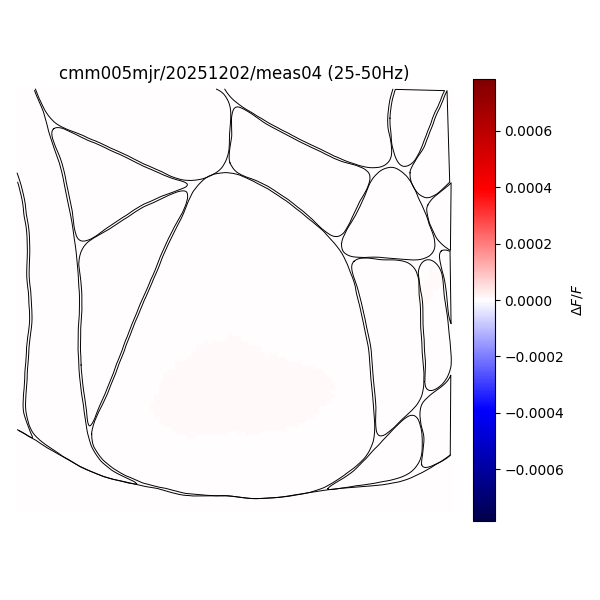

: 

In [ ]:
# 1) Load movie + outlines
plt.close('all')

path_movie = r"Y:/Voltage/VisualConsciousness/Analysis/Visual/cmm007mjr/20251205/meas00/cG_unmixedTR_dFF_denoised.h5"
path_movie = r"Y:/Voltage/VisualConsciousness/Analysis/Visual/cmm005mjr/20251202/meas04/cG_unmixedTR_dFF_denoised.h5"
mov, meta = load_movie_and_specs(path_movie, t_start=9070, t_stop=9300)
outlines_px = outlines_to_pixel_coords(meta["raw_outlines"], meta["binning"], meta["spaceorigin"])

onsets, offsets = meta["onsets"], meta["offsets"]

# 2) Crop to expanded V1 rectangle (adds 25% bbox width/height on each side)
mov_crop, outlines_crop, bbox = crop_to_expanded_v1_rect(
    mov, outlines_px, v1_index=37, pad_frac=0.25
)

clip_bp = bandpass_movie(
    clip=mov_crop,
    fs=157,          # e.g. 157.0
    f_lo=25,
    f_hi=50,
)

# 3) View (optionally overlay outlines in white)
%matplotlib widget
ui = view_movie(
    clip_bp,
    title="cmm005mjr/20251202/meas04 (25-50Hz)",
    interval_ms=400,
    outlines_px=outlines_crop,
    show_outlines=True,          # set False to hide
    outline_color="black",
    outline_lw=0.7,
)
ui

In [ ]:
save_movie(
    clip_bp[70:150],
    out_avi_path="Y:/Voltage/VisualConsciousness/Analysis/Visual/cmm005mjr/20251202/meas04/illustrations/gamma_waves_1.avi",
    title="cmm005mjr/20251202/meas04 (starting frame 9070) \n bandpassed 25-50Hz, slowed down~60x",
    interval_ms=400,
    outlines_px=outlines_crop,
    show_outlines=True,
)

'Y:/Voltage/VisualConsciousness/Analysis/Visual/cmm005mjr/20251202/meas04/illustrations/gamma_waves_1.avi'

In [160]:
onsets

array([  423,  1057,  1936,  2591,  3169,  3739,  4219,  4790,  5290,
        5873,  6344,  6819,  7500,  8007,  8524,  9126,  9679, 10314,
       10898, 11379, 11990, 12661, 13259, 13825, 14354, 14944, 15548,
       16013, 16518, 17122, 17606, 18087, 18788, 19294, 19796, 20372,
       20979, 21486, 22000, 22626, 23140, 23693, 24218, 24842, 25376,
       25853, 26345, 26929, 27399])

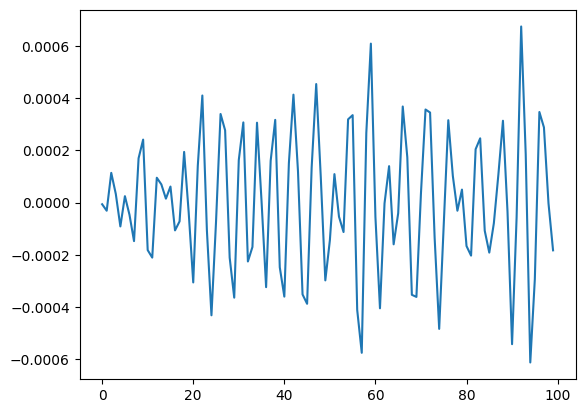

In [137]:
%matplotlib inline
plt.close('all')
plt.plot(clip_bp[:100,50,50])
plt.show()

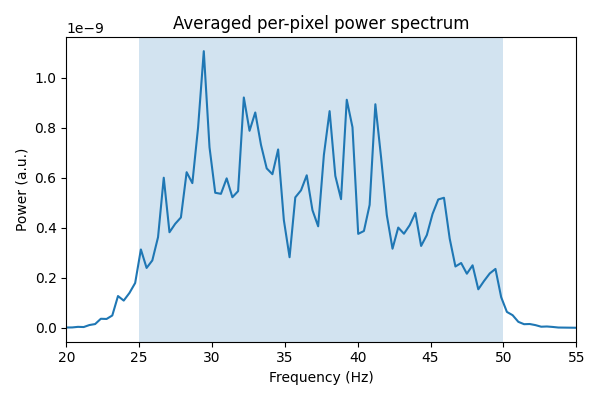

In [113]:
freqs, avg_psd, band_map = movie_power_spectrum(
    clip_bp,
    fs=157,
    band=(25, 50),
    detrend=True,
    window="hann",
    average="mean",
    plot=True,
)